In [1]:
# Importation des bibliothèques
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [2]:
df= pd.read_csv("/content/global_power_plant_database.csv")
df.head()

/tmp/ipykernel_1090/3986997057.py:1: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  df= pd.read_csv("/content/global_power_plant_database.csv")


,country,country_long,name,gppd_idnr,capacity_mw,latitude,longitude,primary_fuel,other_fuel1,other_fuel2,...,estimated_generation_gwh_2013,estimated_generation_gwh_2014,estimated_generation_gwh_2015,estimated_generation_gwh_2016,estimated_generation_gwh_2017,estimated_generation_note_2013,estimated_generation_note_2014,estimated_generation_note_2015,estimated_generation_note_2016,estimated_generation_note_2017
0,AFG,Afghanistan,Kajaki Hydroelectric Power Plant Afghanistan,GEODB0040538,33.0,32.322,65.1190,Hydro,NaN,NaN,...,123.77,162.90,97.39,137.76,119.50,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1
1,AFG,Afghanistan,Kandahar DOG,WKS0070144,10.0,31.670,65.7950,Solar,NaN,NaN,...,18.43,17.48,18.25,17.70,18.29,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE
2,AFG,Afghanistan,Kandahar JOL,WKS0071196,10.0,31.623,65.7920,Solar,NaN,NaN,...,18.64,17.58,19.10,17.62,18.72,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE
3,AFG,Afghanistan,Mahipar Hydroelectric Power Plant Afghanistan,GEODB0040541,66.0,34.556,69.4787,Hydro,NaN,NaN,...,225.06,203.55,146.90,230.18,174.91,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1
4,AFG,Afghanistan,Naghlu Dam Hydroelectric Power Plant Afghanistan,GEODB0040534,100.0,34.641,69.7170,Hydro,NaN,NaN,...,406.16,357.22,270.99,395.38,350.80,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1


In [3]:
print(f"Nombre de lignes : {df.shape}") # dimension du dataset

Nombre de lignes : (34936, 36)


In [4]:
# Calculer le nombre de lignes en doublons
num_duplicates = df.duplicated().sum()
print(f"Nombre de lignes en doublons : {num_duplicates}")

Nombre de lignes en doublons : 0


In [5]:
print("Nombre de valeurs manquantes par colonne:")
print(df.isnull().sum())
print("\nPourcentage de valeurs manquantes par colonne:")
print((df.isnull().sum() / len(df)) * 100)

Nombre de valeurs manquantes par colonne:
country                               0
country_long                          0
name                                  0
gppd_idnr                             0
capacity_mw                           0
latitude                              0
longitude                             0
primary_fuel                          0
other_fuel1                       32992
other_fuel2                       34660
other_fuel3                       34844
commissioning_year                17489
owner                             14068
source                               15
url                                  18
geolocation_source                  419
wepp_id                           18702
year_of_capacity_data             20049
generation_gwh_2013               28519
generation_gwh_2014               27710
generation_gwh_2015               26733
generation_gwh_2016               25792
generation_gwh_2017               25436
generation_gwh_2018               2529

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34936 entries, 0 to 34935
Data columns (total 36 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   country                         34936 non-null  object 
 1   country_long                    34936 non-null  object 
 2   name                            34936 non-null  object 
 3   gppd_idnr                       34936 non-null  object 
 4   capacity_mw                     34936 non-null  float64
 5   latitude                        34936 non-null  float64
 6   longitude                       34936 non-null  float64
 7   primary_fuel                    34936 non-null  object 
 8   other_fuel1                     1944 non-null   object 
 9   other_fuel2                     276 non-null    object 
 10  other_fuel3                     92 non-null     object 
 11  commissioning_year              17447 non-null  float64
 12  owner                           

In [7]:
for col in df.select_dtypes(include='object'):
    converted = pd.to_numeric(df[col], errors='coerce')

    if converted.notna().sum() == len(df):
        print(col, "peut être convertie en numérique")

Aucune colonne object ne doit être convertie en type numérique, car elles représentent des informations textuelles, des identifiants ou des catégories.

In [8]:
# Identification des variables qualitatives (objets/catégories)
qualitative_vars = df.select_dtypes(include=['object', 'category']).columns.tolist()

# Identification des variables quantitatives (numériques)
quantitative_vars = df.select_dtypes(include=['number']).columns.tolist()

print(f"Variables qualitatives : {qualitative_vars}")
print(f"Variables quantitatives : {quantitative_vars}")

Variables qualitatives : ['country', 'country_long', 'name', 'gppd_idnr', 'primary_fuel', 'other_fuel1', 'other_fuel2', 'other_fuel3', 'owner', 'source', 'url', 'geolocation_source', 'wepp_id', 'generation_data_source', 'estimated_generation_note_2013', 'estimated_generation_note_2014', 'estimated_generation_note_2015', 'estimated_generation_note_2016', 'estimated_generation_note_2017']
Variables quantitatives : ['capacity_mw', 'latitude', 'longitude', 'commissioning_year', 'year_of_capacity_data', 'generation_gwh_2013', 'generation_gwh_2014', 'generation_gwh_2015', 'generation_gwh_2016', 'generation_gwh_2017', 'generation_gwh_2018', 'generation_gwh_2019', 'estimated_generation_gwh_2013', 'estimated_generation_gwh_2014', 'estimated_generation_gwh_2015', 'estimated_generation_gwh_2016', 'estimated_generation_gwh_2017']


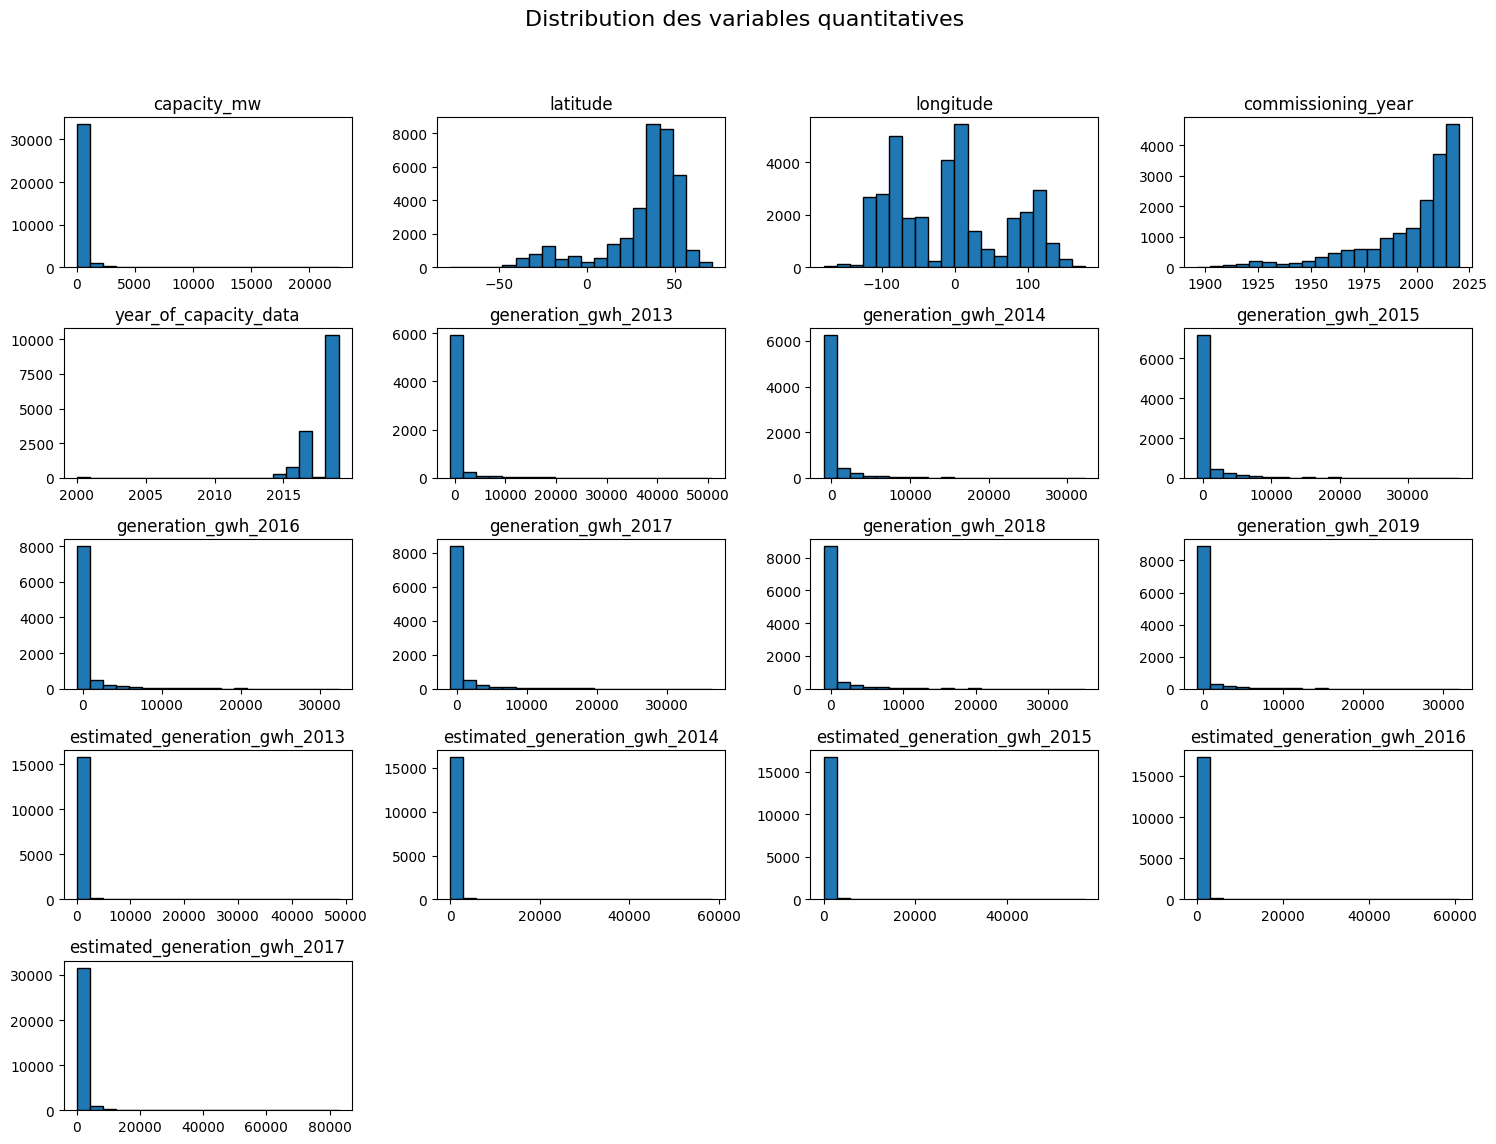

In [9]:
# Représentation des distributions des variables quantitatives
df[quantitative_vars].hist(figsize=(15, 12), bins=20, grid=False, edgecolor='black')
plt.suptitle('Distribution des variables quantitatives', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

Nettoyage des données

La littérature recommande qu'une variable comportant plus de 60 à 70 % de valeurs manquantes apporte généralement peu d'information et que son imputation risque d'introduire un biais important.

In [10]:
# ==========================
# 1. Supprimer les colonnes très incomplètes (>60 %)
# ==========================

cols_to_drop = [
    'other_fuel1',
    'other_fuel2',
    'other_fuel3',
    'generation_gwh_2013',
    'generation_gwh_2014',
    'generation_gwh_2015',
    'generation_gwh_2016',
    'generation_gwh_2017',
    'generation_gwh_2018',
    'generation_gwh_2019',
    'generation_data_source'
]

df.drop(columns=cols_to_drop, inplace=True)

# ==========================
# 2. Imputation des variables numériques
# ==========================

numeric_cols = [
    'year_of_capacity_data',
    'commissioning_year',
    'estimated_generation_gwh_2013',
    'estimated_generation_gwh_2014',
    'estimated_generation_gwh_2015',
    'estimated_generation_gwh_2016',
    'estimated_generation_gwh_2017'
]

for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

# ==========================
# 3. Imputation des variables catégorielles
# ==========================

categorical_cols = [
    'owner',
    'source',
    'url',
    'geolocation_source',
    'wepp_id',
    'estimated_generation_note_2014',
    'estimated_generation_note_2017',
    'estimated_generation_note_2016',
    'estimated_generation_note_2015',
    'estimated_generation_note_2013'
]

for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# ==========================
# 4. Vérification
# ==========================

missing = (df.isnull().mean()*100).sort_values(ascending=False)

print(missing)

country                           0.0
country_long                      0.0
name                              0.0
gppd_idnr                         0.0
capacity_mw                       0.0
latitude                          0.0
longitude                         0.0
primary_fuel                      0.0
commissioning_year                0.0
owner                             0.0
source                            0.0
url                               0.0
geolocation_source                0.0
wepp_id                           0.0
year_of_capacity_data             0.0
estimated_generation_gwh_2013     0.0
estimated_generation_gwh_2014     0.0
estimated_generation_gwh_2015     0.0
estimated_generation_gwh_2016     0.0
estimated_generation_gwh_2017     0.0
estimated_generation_note_2013    0.0
estimated_generation_note_2014    0.0
estimated_generation_note_2015    0.0
estimated_generation_note_2016    0.0
estimated_generation_note_2017    0.0
dtype: float64


commentaire : Supprimer les variables avec une proportion très élevée de valeurs manquantes (> 60–70 %), car leur imputation est peu fiable et peut introduire un biais important.
Imputer les variables numériques par la médiane, particulièrement lorsque la distribution est asymétrique ou contient des valeurs extrêmes. La médiane est plus robuste que la moyenne.
Imputer les variables catégorielles par une catégorie explicite ("Unknown"), ce qui permet de conserver toutes les observations et d'indiquer au modèle que l'information est absente plutôt que d'inventer une modalité.

In [11]:
# Résumé statistique des colonnes numériques (moyenne, écart-type, min, max, quartiles)
print("Statistiques clés des colonnes numériques :")
display(df.describe())

Statistiques clés des colonnes numériques :


,capacity_mw,latitude,longitude,commissioning_year,year_of_capacity_data,estimated_generation_gwh_2013,estimated_generation_gwh_2014,estimated_generation_gwh_2015,estimated_generation_gwh_2016,estimated_generation_gwh_2017
count,34936.000000,34936.000000,34936.000000,34936.000000,34936.000000,34936.000000,34936.000000,34936.000000,34936.000000,34936.000000
mean,163.355148,32.816637,-6.972803,2002.213173,2018.667134,125.205717,129.424463,128.846972,132.232824,681.505825
std,489.636072,22.638603,78.405850,17.215166,1.117514,816.018694,890.157657,891.256782,899.269378,2424.229996
min,1.000000,-77.847000,-179.977700,1896.000000,2000.000000,1.120000,0.870000,0.440000,0.300000,0.000000
25%,4.900000,29.256475,-77.641550,2007.000000,2019.000000,27.620000,28.250000,26.830000,27.067500,8.960000
50%,16.745000,39.727750,-2.127100,2007.000000,2019.000000,27.620000,28.250000,26.830000,27.555000,37.590000
75%,75.344250,46.263125,49.502675,2007.000000,2019.000000,27.620000,28.250000,26.830000,28.040000,195.640000
max,22500.000000,71.292000,179.388700,2020.000000,2019.000000,48675.060000,58470.770000,57113.350000,60859.730000,82810.770000


In [12]:
# Répartition des centrales par pays et par type de combustible
repartition = pd.crosstab(df['country_long'], df['primary_fuel'])

# Affichage des 10 premiers pays pour plus de clarté
print("Répartition des centrales électriques par pays et combustible :")
repartition.head(10)

Répartition des centrales électriques par pays et combustible :


primary_fuel,Biomass,Coal,Cogeneration,Gas,Geothermal,Hydro,Nuclear,Oil,Other,Petcoke,Solar,Storage,Waste,Wave and Tidal,Wind
country_long,,,,,,,,,,,,,,,
Afghanistan,0,0,0,1,0,6,0,0,0,0,2,0,0,0,0
Albania,0,0,0,0,0,7,0,0,1,0,0,0,0,0,0
Algeria,0,0,0,31,0,1,0,0,0,0,27,0,0,0,0
Angola,0,0,0,3,0,5,0,6,0,0,0,0,0,0,0
Antarctica,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1
Argentina,0,9,0,57,0,50,3,96,2,0,7,0,0,0,12
Armenia,0,0,0,3,0,4,1,0,0,0,0,0,0,0,0
Australia,25,28,0,134,0,73,0,42,0,0,69,0,50,0,65
Austria,0,0,0,3,0,96,0,0,0,0,0,0,0,0,4


#### Distribution par pays

In [13]:
country_counts = df['country_long'].value_counts()
print(country_counts.head(10))

country_long
United States of America    9833
China                       4235
United Kingdom              2751
Brazil                      2360
France                      2155
India                       1589
Germany                     1309
Canada                      1159
Spain                        829
Russia                       545
Name: count, dtype: int64


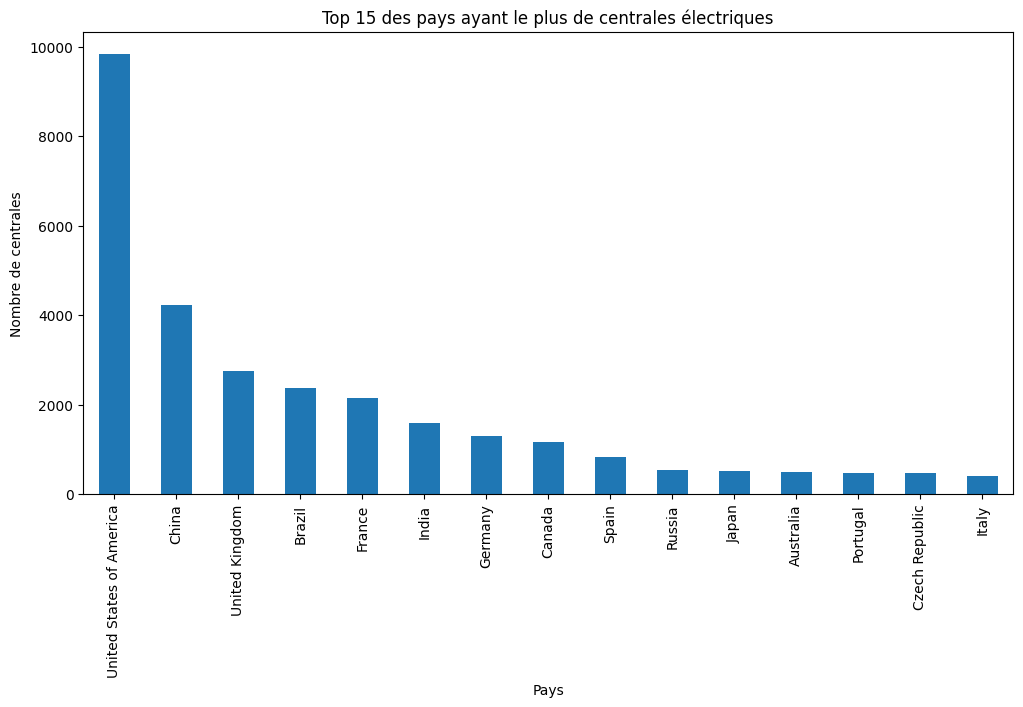

In [14]:
country_counts.head(15).plot(kind='bar', figsize=(12,6))
plt.title("Top 15 des pays ayant le plus de centrales électriques")
plt.xlabel("Pays")
plt.ylabel("Nombre de centrales")
plt.xticks(rotation=90)

plt.show()

Les États-Unis possèdent le plus grand nombre de centrales électriques, suivis de la Chine, de l'Inde et du Brésil. Cela reflète l'importance de leur production énergétique et la taille de leur économie.

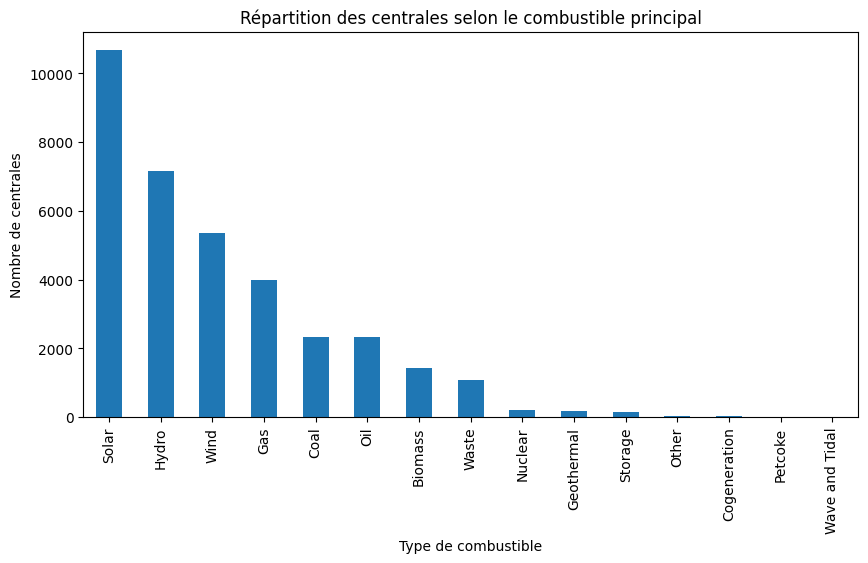

In [15]:
fuel_counts = df['primary_fuel'].value_counts()
fuel_counts.plot(kind='bar', figsize=(10,5))
plt.title("Répartition des centrales selon le combustible principal")
plt.xlabel("Type de combustible")
plt.ylabel("Nombre de centrales")
plt.show()

Le solaire représente le type de centrale le plus fréquent, suivie de l'hydroélectricité, du charbon et du gaz naturel. Les centrales nucléaires sont beaucoup moins nombreuses.

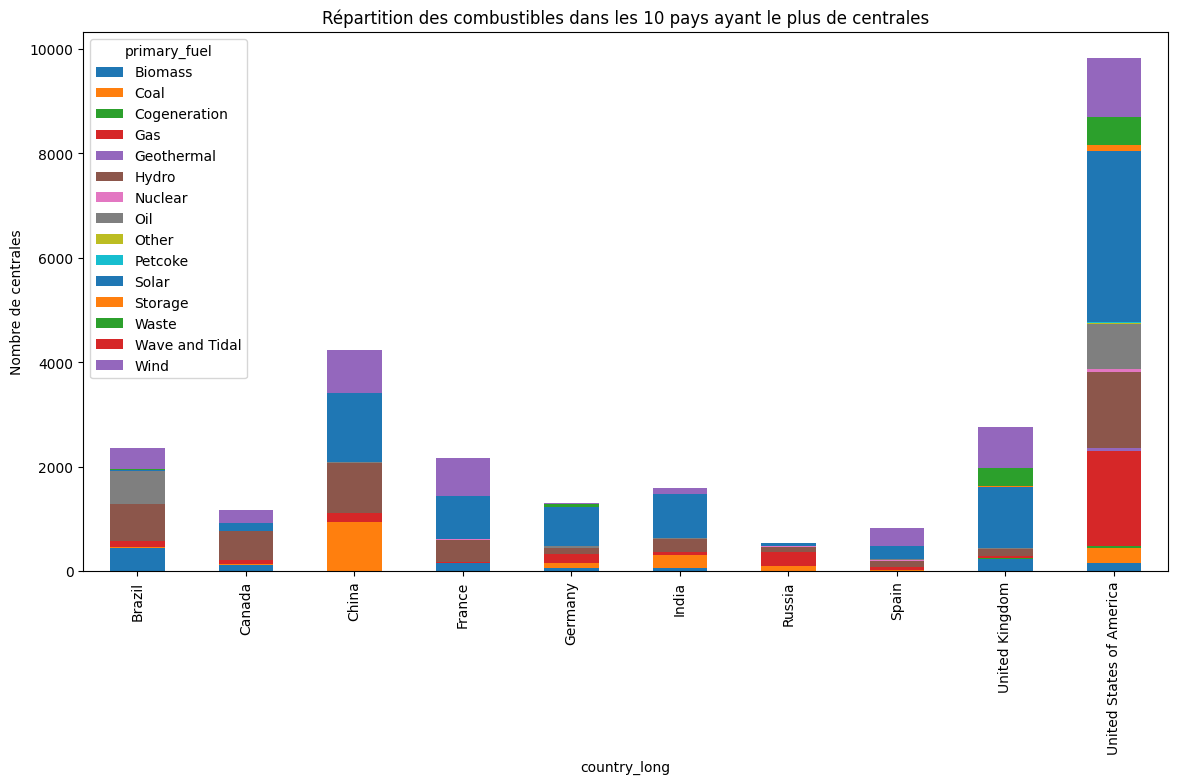

In [16]:
top10 = df['country_long'].value_counts().head(10).index
top_country = pd.crosstab(
    df[df['country_long'].isin(top10)]['country_long'],
    df[df['country_long'].isin(top10)]['primary_fuel']
)
top_country.plot(
    kind='bar',
    stacked=True,
    figsize=(14,7)
)

plt.title("Répartition des combustibles dans les 10 pays ayant le plus de centrales")

plt.ylabel("Nombre de centrales")

plt.show()

La Biomass est la plus utilisé par l'ensemble des Top 10 des Etats pour les centrales.

Analyse statistique de la puissance développée en fonction du carburant

In [17]:
results = []

# Parcourir chaque type de carburant
for fuel in df['primary_fuel'].unique():

    capacities = df[df['primary_fuel'] == fuel]['capacity_mw']

    results.append({
        "Fuel": fuel,
        "Count": len(capacities),
        "Mean (MW)": np.mean(capacities),
        "Median (MW)": np.median(capacities),
        "Min (MW)": np.min(capacities),
        "Max (MW)": np.max(capacities),
        "Std (MW)": np.std(capacities),
        "Variance": np.var(capacities),
        "25%": np.percentile(capacities,25),
        "75%": np.percentile(capacities,75)
    })

stats_df = pd.DataFrame(results)

stats_df.sort_values(by="Mean (MW)", ascending=False)

,Fuel,Count,Mean (MW),Median (MW),Min (MW),Max (MW),Std (MW),Variance,25%,75%
6,Nuclear,195,2091.855179,1888.00000,20.0,8212.00,1300.162646,1.690423e+06,1146.650,2668.350000
7,Coal,2330,843.579828,600.00000,1.2,7000.00,887.996568,7.885379e+05,200.000,1200.000000
2,Gas,3998,373.449375,147.50000,1.0,8865.00,560.863990,3.145684e+05,28.425,532.066775
11,Petcoke,12,202.048125,65.48875,4.7,1707.30,456.679766,2.085564e+05,22.375,123.150000
0,Hydro,7156,147.171551,20.00000,1.0,22500.00,549.770911,3.022481e+05,5.395,93.600000
4,Oil,2320,112.878754,9.00000,1.0,6794.00,391.924545,1.536048e+05,2.500,48.000000
14,Cogeneration,41,98.731707,31.90000,1.6,1404.00,279.950473,7.837227e+04,7.500,50.000000
3,Other,43,84.020000,40.00000,4.5,845.26,144.185002,2.078931e+04,17.000,97.500000
12,Geothermal,189,67.130952,30.00000,1.0,1163.00,114.337205,1.307300e+04,18.200,80.000000
10,Wave and Tidal,10,55.220000,5.00000,1.0,254.00,96.235106,9.261196e+03,1.400,22.250000


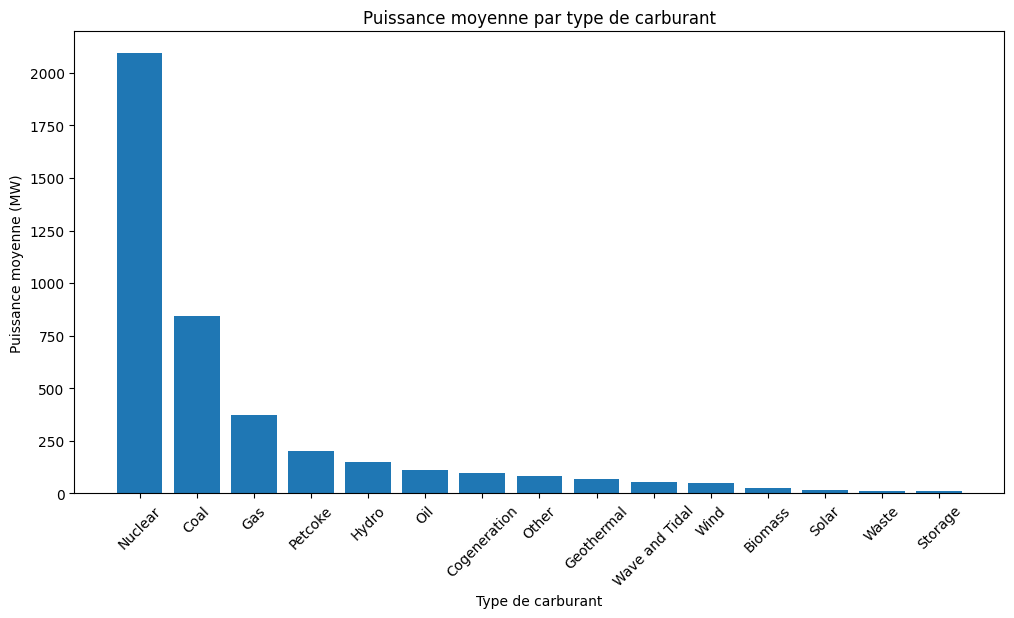

In [18]:
stats_df = stats_df.sort_values("Mean (MW)", ascending=False)

plt.figure(figsize=(12,6))

plt.bar(stats_df["Fuel"], stats_df["Mean (MW)"])

plt.title("Puissance moyenne par type de carburant")
plt.xlabel("Type de carburant")
plt.ylabel("Puissance moyenne (MW)")

plt.xticks(rotation=45)

plt.show()

Test Statistique de ANOVA (Variable quantitative et Variable quantitative)

> Est-ce que la puissance moyenne (capacity_mw) est différente selon le type de carburant (primary_fuel) ?

*Hypothèses*

H0 : la puissance moyenne est la même pour tous les types de carburant

H1 : au moins un type de carburant a une puissance moyenne différente



In [19]:
groups = []
for fuel in df['primary_fuel'].unique():
    groups.append(
        df[df['primary_fuel'] == fuel]['capacity_mw'].dropna()
    )
f_stat, p_value = stats.f_oneway(*groups)
print("F-statistic:", f_stat)
print("p-value:", p_value)
alpha = 0.05
if p_value < alpha:
    print("Reject H0")
    print("La puissance moyenne diffère significativement selon le type de carburant.")
else:
    print("Fail to reject H0")
    print("Aucune différence significative entre les types de carburant.")

F-statistic: 967.4600353089303
p-value: 0.0
Reject H0
La puissance moyenne diffère significativement selon le type de carburant.


Commentaire : La p-value ≈ 0.0 est extrêmement inférieure au seuil classique de 5% (0.05).
Il existe des différences statistiquement significatives entre les puissances moyennes des centrales selon leur type de carburant.

Le test ANOVA a révélé une différence statistiquement significative entre les puissances moyennes des centrales électriques selon le type de carburant (F = 967.46, p < 0.001).
Cela indique que le type de carburant est un facteur déterminant dans la capacité de production des centrales électriques.

Analyse des Series Temporelles

In [20]:
df_time = df[['commissioning_year', 'capacity_mw', 'primary_fuel']].dropna()
years = np.sort(df_time['commissioning_year'].unique())
mean_capacity = []
for year in years:
    capacities = df_time[df_time['commissioning_year'] == year]['capacity_mw']
    mean_capacity.append(np.mean(capacities))

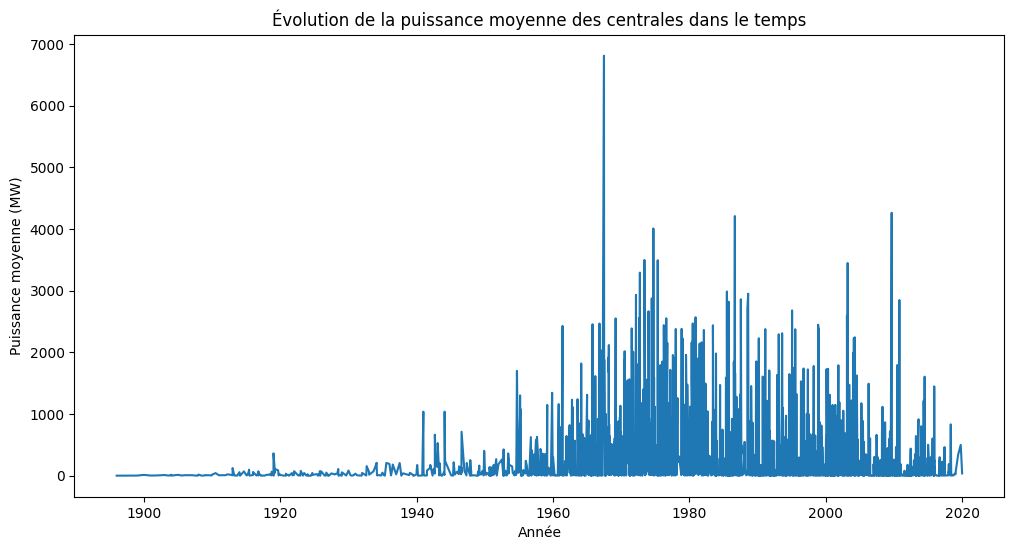

In [21]:
plt.figure(figsize=(12,6))
plt.plot(years, mean_capacity)
plt.title("Évolution de la puissance moyenne des centrales dans le temps")
plt.xlabel("Année")
plt.ylabel("Puissance moyenne (MW)")
plt.show()

In [22]:
counts = []
for year in years:
    counts.append(len(df_time[df_time['commissioning_year'] == year]))

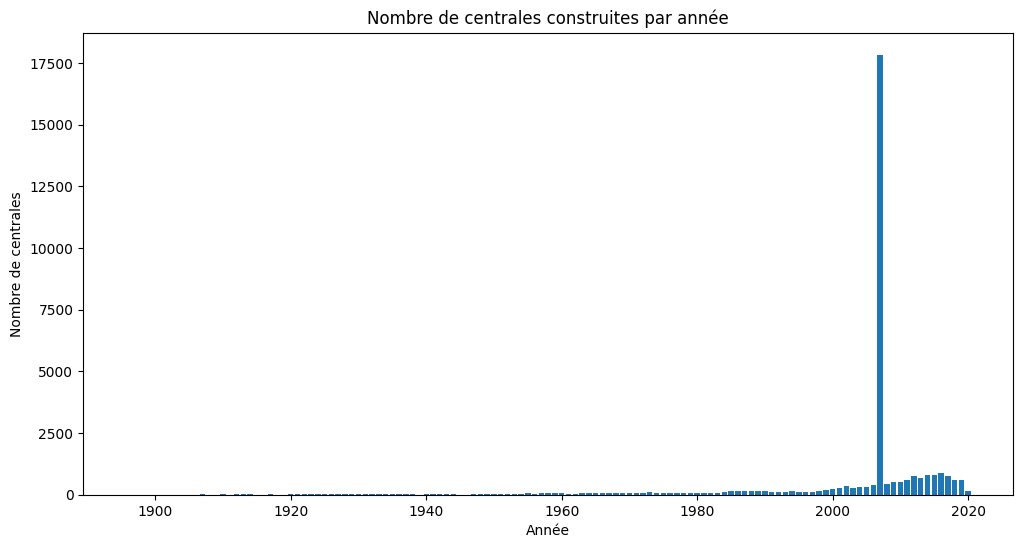

In [23]:
plt.figure(figsize=(12,6))
plt.bar(years, counts)

plt.title("Nombre de centrales construites par année")
plt.xlabel("Année")
plt.ylabel("Nombre de centrales")
plt.show()

L'année 2007 a enregistré un record dans la creation de centrale. apres cette date nous constatons une augmentation modéré et ensuite une dimunition.

Mix énergétique dans le temps.




In [24]:
df_mix = df[['commissioning_year', 'primary_fuel', 'capacity_mw']].dropna()
mix = (
    df_mix
    .groupby(['commissioning_year', 'primary_fuel'])['capacity_mw']
    .sum()
    .reset_index()
)
pivot = mix.pivot(
    index='commissioning_year',
    columns='primary_fuel',
    values='capacity_mw'
).fillna(0)

pivot.head()

primary_fuel,Biomass,Coal,Cogeneration,Gas,Geothermal,Hydro,Nuclear,Oil,Other,Petcoke,Solar,Storage,Waste,Wave and Tidal,Wind
commissioning_year,,,,,,,,,,,,,,,
1896.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1899.0,0.0,0.0,0.0,0.0,0.0,3.2,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1900.0,0.0,0.0,0.0,61.0,0.0,25.7,0.0,2.24,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1901.0,0.0,0.0,0.0,0.0,0.0,7.4,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1902.0,0.0,0.0,0.0,0.0,0.0,23.5,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0


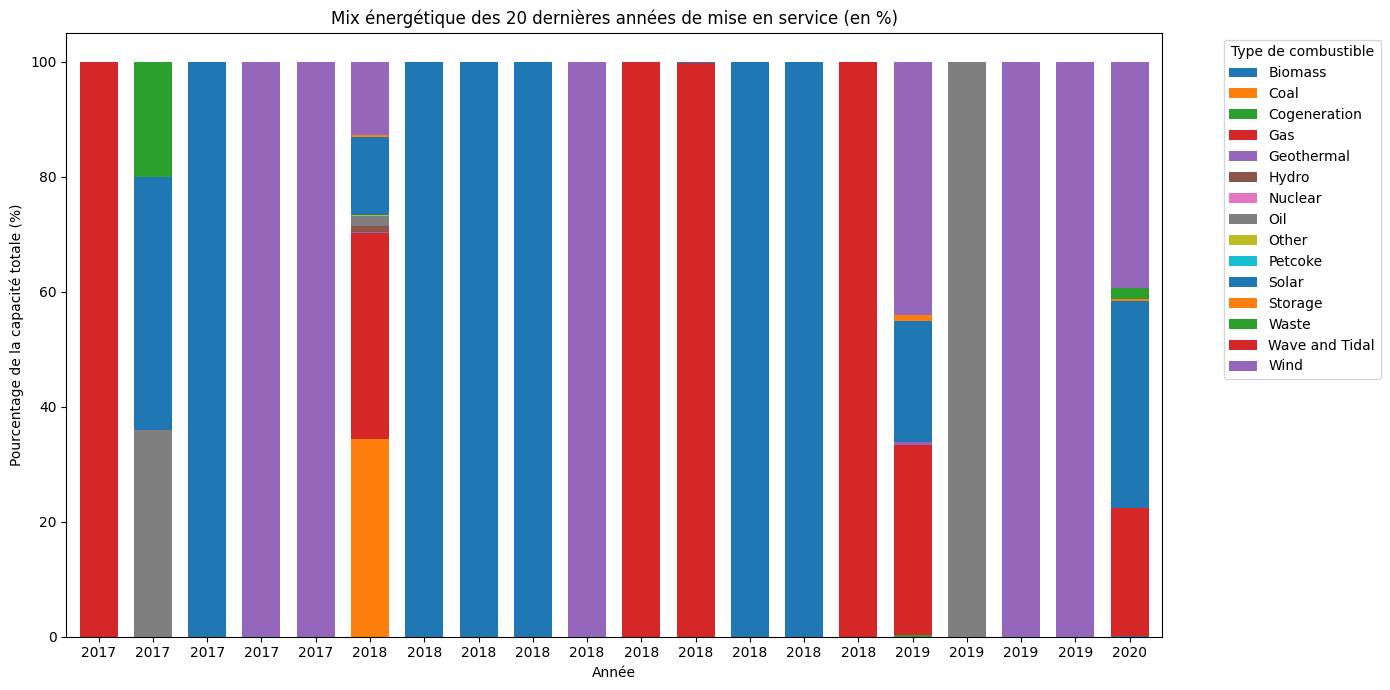

In [25]:
# Sélection des 20 dernières années présentes dans le pivot
pivot_last_20 = pivot.tail(20)

# Calcul du pourcentage pour chaque type de combustible par année
mix_percent_20 = pivot_last_20.div(pivot_last_20.sum(axis=1), axis=0) * 100

# Création du graphique en barres empilées
ax = mix_percent_20.plot(kind='bar', stacked=True, figsize=(14, 7), width=0.7)

plt.title("Mix énergétique des 20 dernières années de mise en service (en %)")
plt.xlabel("Année")
plt.ylabel("Pourcentage de la capacité totale (%)")
plt.legend(title="Type de combustible", bbox_to_anchor=(1.05, 1), loc='upper left')

# Formater les étiquettes de l'axe X pour n'afficher que l'année entière
# Note: conversion en float puis int pour gérer les index numériques
ax.set_xticklabels([int(float(label.get_text())) for label in ax.get_xticklabels()], rotation=0)

plt.tight_layout()
plt.show()

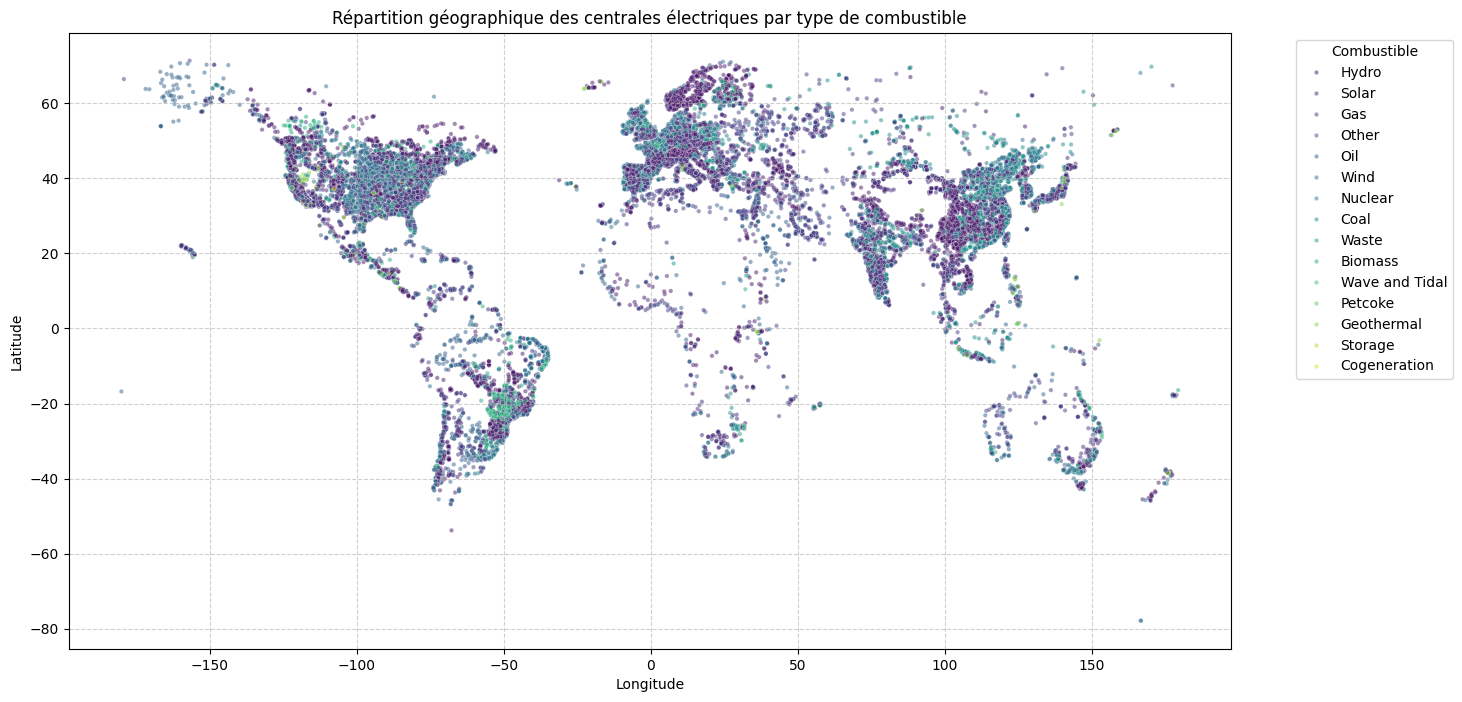

In [26]:
plt.figure(figsize=(15, 8))
sns.scatterplot(data=df, x='longitude', y='latitude', hue='primary_fuel', palette='viridis', alpha=0.5, s=10)
plt.title("Répartition géographique des centrales électriques par type de combustible")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Combustible')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

La représentation géographique montre une forte concentration des centrales électriques dans les régions fortement industrialisées, notamment en Amérique du Nord, en Europe et en Asie. Les centrales hydroélectriques sont souvent situées à proximité des grands cours d'eau, tandis que les centrales solaires sont davantage implantées dans les régions bénéficiant d'un fort ensoleillement.